In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import quantstats as qs
import empyrical as ep
import os
import matplotlib.pyplot as plt; plt.rcdefaults()

In [111]:
!pip install fanchart

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 3.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 6.3 MB/s eta 0:00:0000:0100:01m
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.4
    Uninstalling numpy-1.23.4:
      Successfully uninstalled numpy-1.23.4
  Attempting uninstall: pandas
    Found existing installation: pandas 1.5.2
    Uninstalling pandas-1.5.2:
      Successfully uninstalled pandas-1.5.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
openbb 3.2.3 requires grpcio<2.0.0,>=1.51.1, but you have grpcio 1.49.1 which is incompatible.
openbb 3.2.3 requires numpy==1.23.4, but you have numpy 1.26.2 which is incompatible.
openbb 3.2.3 requires pandas<2.0.0,>=1.5.0, but you have pandas 2.1.3 which is incompatible.
numba 0.56.4 requires numpy<1.24,>=1.18, but you have numpy 1.26.2 

In [74]:
# !pip install -e /Users/safishajjouz/GitHub/QuantitativePortfolioManagement
# set env to: jupyter_env 
from pyData.getdata import get_US_yields, get_FX_spots
from myPortfolioManagement.myData import get_stock_prices
from myPortfolioManagement.myDataPreparation import make_sma
from myPortfolioManagement.myBacktesting import performance, prep_dist, plot_fan_chart
from myPortfolioManagement.myPerformanceMetrics import performance_overview, get_main_stats
from myPortfolioManagement.myPlots import monthly_heatmap
from myPortfolioManagement.myBootstrapping import bootstrappingTS
from myPortfolioManagement.myReturns import returns_from_prices

In [4]:
# download US Yields
# ======================================================================================================================
df_USyields = get_US_yields(freq='d', add_fed_rate=True)

# define slope
# ======================================================================================================================
df = df_USyields[['2Y', 'DFF', '1Y']].copy()
df['Slope2Y'] = df['DFF'] - df['2Y']  # if 2Y > DFF, means markets expect Fed to increase rates

<AxesSubplot: xlabel='Date'>

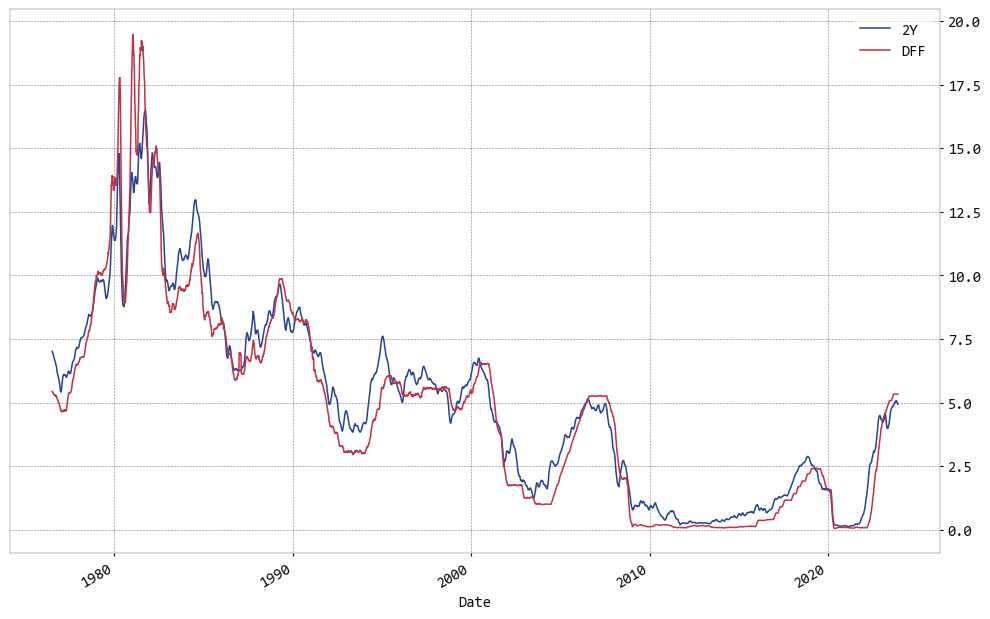

In [5]:
# check
df[['2Y', 'DFF']].dropna().fillna(method='bfill').rolling(30).mean().plot(figsize= (12,8))

In [6]:
# define momentum
# ======================================================================================================================
df_sm = make_sma(df[['Slope2Y']], spans=[50])
df_all = df.join(df_sm).dropna()

# generate signal
# ======================================================================================================================
df_all['Signal'] = np.where(df_all['Slope2Y'] > df_all['Slope2Y_sm50'], 1, -1)

<AxesSubplot: xlabel='Date'>

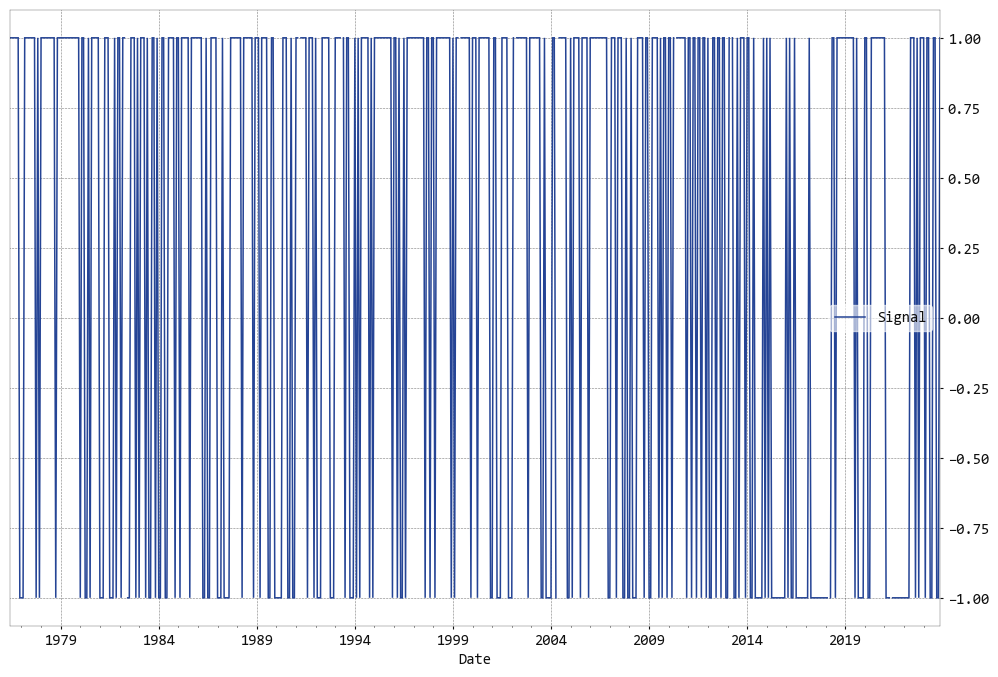

In [67]:
df_all[['Signal']].dropna().asfreq('BM').plot(figsize=(12,8))

In [8]:
# Get data trading instruments: EURUSD, Stocks, Japan
# ======================================================================================================================
df_stock = get_stock_prices(yahoo_tickers=['^IXIC'], wide_format=True)
df_stock = df_stock.rename(columns={'^IXIC': 'Nasdaq'})
#df_fx = get_FX_spots(currencies=['EUR', 'JPY'], wide_format=True)
df_fx = get_FX_spots(currencies=['JPY'], wide_format=True)

df_assets = pd.concat([df_stock, df_fx], axis=1)
df_assets.index.name = df_all.index.name

# merge all
# ======================================================================================================================
df_all = df_all.join(df_assets)

get_stock_prices took 642.46ms


<AxesSubplot: xlabel='Date'>

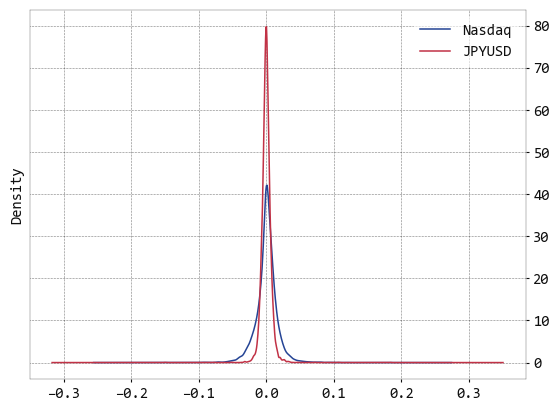

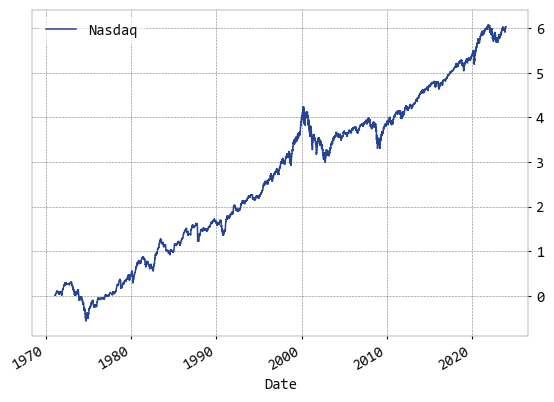

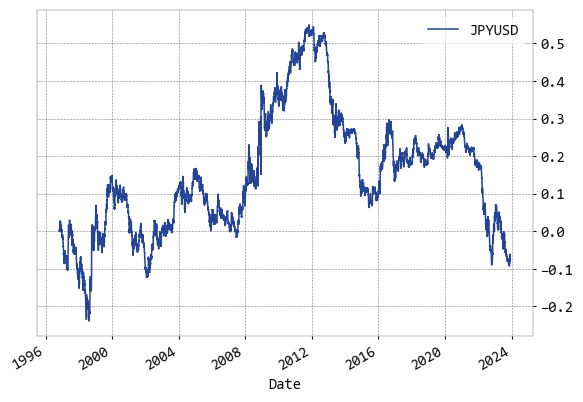

In [69]:
returns_from_prices(df_assets).dropna().plot.density()
returns_from_prices(df_assets[['Nasdaq']]).cumsum().plot()
returns_from_prices(df_assets[['JPYUSD']]).cumsum().plot()

<AxesSubplot: xlabel='Date'>

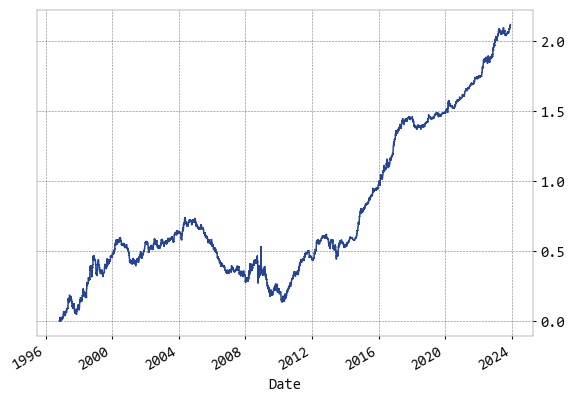

In [10]:
performance(signal=df_all['Signal'], returns=df_all['JPYUSD'].pct_change()).dropna().cumsum().plot()

In [11]:
# performance
# ======================================================================================================================
df_perm = pd.DataFrame(index=df_all.index)
for col in ['JPYUSD']:
    # df_perm[col] = performance(signal=df_all['Signal'], returns=np.log(df_all[col]).diff()).cumsum()
    ret_temp = returns_from_prices(df_all[col])
    df_perm[col] = performance(signal=df_all['Signal'], returns=ret_temp)
    df_perm[col + '_no_TC'] = performance(signal=df_all['Signal'], returns=ret_temp, bps=0)
    # df_perm[col + 'str2'] = performance(signal=df_all['Signal2'], returns=np.log(df_all[col]).diff())

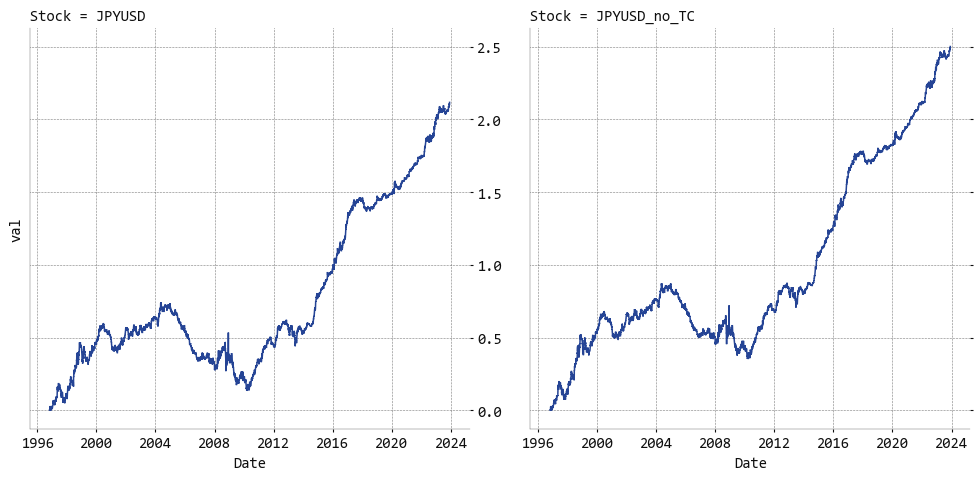

In [12]:
# from wide to long to plot
# ======================================================================================================================
dfm = df_perm.cumsum().dropna().reset_index().melt(id_vars='Date', var_name='Stock', value_name='val')
dfm['asset'] = [x.split('str')[0] for x in dfm.Stock]
g = sns.relplot(data=dfm, x='Date', y='val', col='Stock', col_wrap=3, kind='line')

In [14]:
# stats
df_perm_stats = performance_overview(df_perm, short=True).sort_values(by=['cagr'], ascending=False)
df_perm_stats

,start,end,total_return,cagr,max_drawdown,yearly_sharpe,yearly_sortino,calmar
JPYUSD_no_TC,1996-10-31,2023-11-30,9.053204,0.088962,-0.451971,0.676459,1.996192,0.196831
JPYUSD,1996-10-31,2023-11-30,5.844886,0.073614,-0.498288,0.576859,1.528667,0.147733


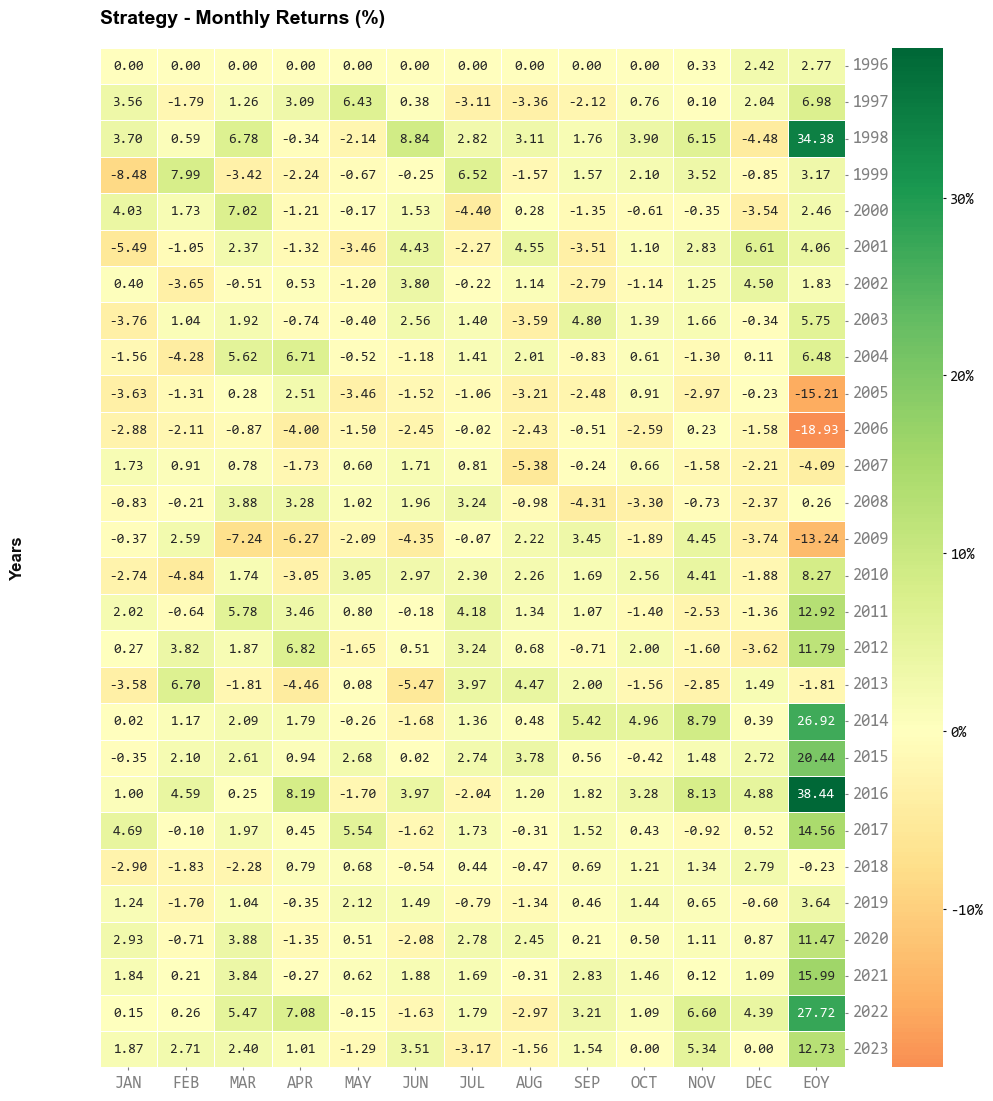

In [15]:
ret_bench = df_stock.pct_change()
df_temp = df_perm[['JPYUSD']].join(ret_bench).dropna()
qs.plots.monthly_returns(df_temp['JPYUSD'], eoy=True)

<AxesSubplot: >

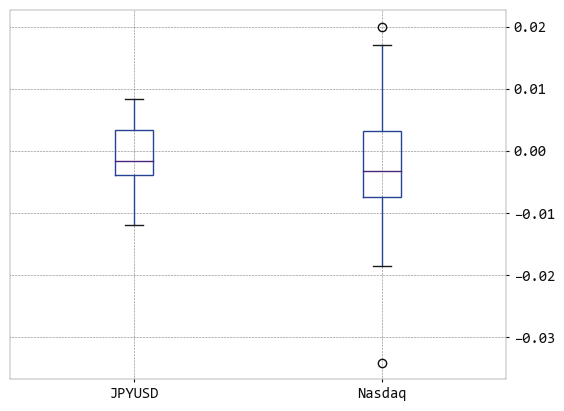

In [63]:
monthly = df_temp.asfreq('BY')
monthly.boxplot()

In [19]:
get_main_stats(df_temp[df_temp.index>='2012-01-01'])

CAGR DONE:   0%|          | 0/2 [00:00<?, ?it/s]

ADJUSTED_SORTINO DONE:   0%|          | 0/2 [00:00<?, ?it/s]

SHARPE DONE:   0%|          | 0/2 [00:00<?, ?it/s]

CALMAR DONE:   0%|          | 0/2 [00:00<?, ?it/s]

MAX_DRAWDOWN DONE:   0%|          | 0/2 [00:00<?, ?it/s]

get_main_stats took 10.982sec


metric,cagr,adjusted_sortino,sharpe,calmar,max_drawdown
JPYUSD,0.146949,1.061128,0.984983,0.581144,-0.170843
Nasdaq,0.151807,0.498663,0.507880,0.277392,-0.369499


In [21]:
ret_boostp = bootstrappingTS(df_perm['JPYUSD'].dropna(), n_samples=10000, bootstrap_type='sb', block_size=365, 
                             optimal_block = True, 
                                          seed=123)

bootstrappingTS took 3.050sec


In [ ]:
stats_boostp = get_main_stats(ret_boostp)

<AxesSubplot: ylabel='Density'>

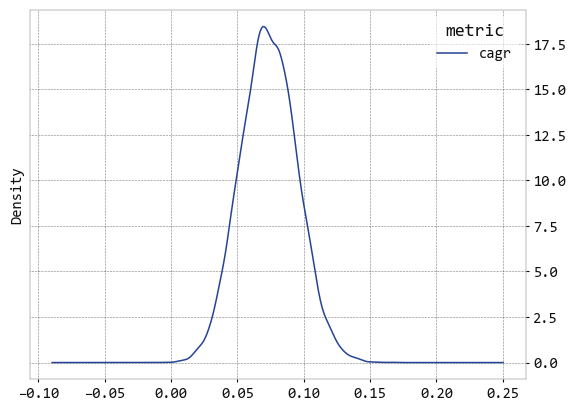

In [23]:
stats_boostp[['cagr']].plot.density()

In [70]:
df_hist = get_main_stats(df_temp)
df_hist

CAGR DONE:   0%|          | 0/2 [00:00<?, ?it/s]

ADJUSTED_SORTINO DONE:   0%|          | 0/2 [00:00<?, ?it/s]

SHARPE DONE:   0%|          | 0/2 [00:00<?, ?it/s]

CALMAR DONE:   0%|          | 0/2 [00:00<?, ?it/s]

MAX_DRAWDOWN DONE:   0%|          | 0/2 [00:00<?, ?it/s]

get_main_stats took 13.145sec


metric,cagr,adjusted_sortino,sharpe,calmar,max_drawdown
JPYUSD,0.072669,0.215711,0.214249,0.099514,-0.498667
Nasdaq,0.086534,0.249683,0.251653,0.075562,-0.780454


In [47]:
boost_mean = ret_boostp.asfreq('BY').mean().mean()*100

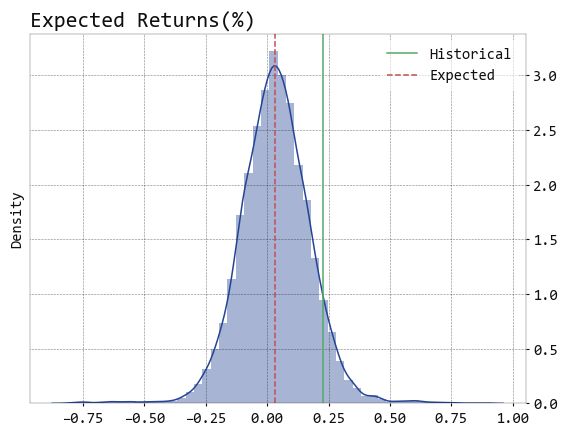

In [62]:
sns.distplot(ret_boostp.asfreq('BY').mean()*100, hist=True)
plt.axvline(x=hist_ret.mean()*100, color='g', linestyle='-', label='Historical')
plt.axvline(x=boost_mean, color='r', linestyle='--', label='Expected')
plt.title('Expected Returns(%)')
plt.legend()

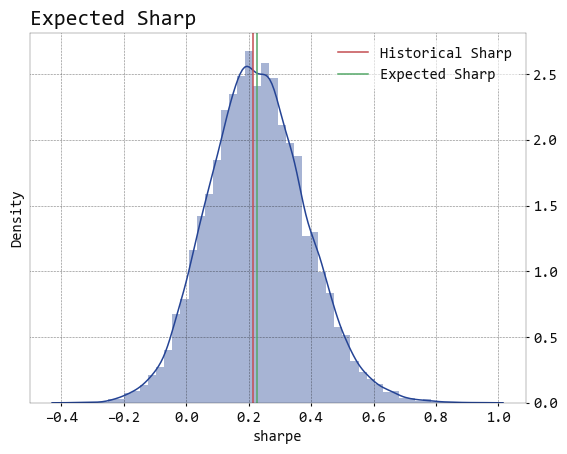

In [55]:
metric = 'sharpe'
hist_sharp = df_hist.loc['JPYUSD']['sharpe']
boost_sharp = stats_boostp[['sharpe']].mean()[0]
sns.distplot(stats_boostp[metric], hist=True)
plt.axvline(x=hist_sharp, color='r', linestyle='-', label = 'Historical Sharp')
plt.axvline(x=boost_sharp, color='g', linestyle='-', label = 'Expected Sharp')
plt.title('Expected Sharp')
plt.legend()

<AxesSubplot: xlabel='JPYUSD', ylabel='Density'>

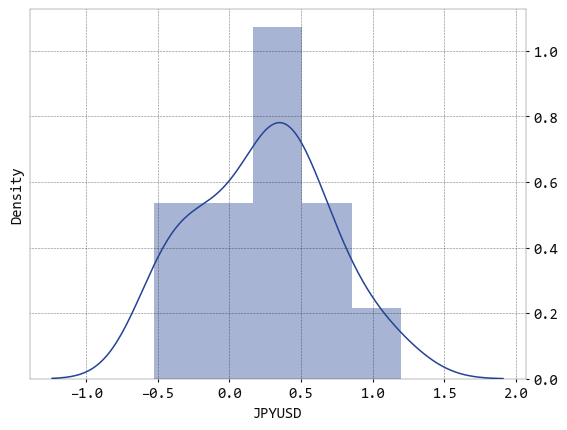

In [56]:
hist_ret = returns_from_prices(df_assets['JPYUSD']).asfreq('BY', normalize = False).dropna()
hist_ret.index = pd.to_datetime(hist_ret.index).normalize()
sns.distplot(hist_ret*100, hist=True)

                           Benchmark    Strategy
-------------------------  -----------  -----------
Start Period               1996-11-01   1996-11-01
End Period                 2023-11-30   2023-11-30
Risk-Free Rate             5.0%         5.0%
Time in Market             100.0%       100.0%

Cumulative Return          835.96%      569.24%
CAGR﹪                     5.86%        4.96%

Sharpe                     0.26         0.24
Prob. Sharpe Ratio         4.14%        23.95%
Smart Sharpe               0.23         0.21
Sortino                    0.37         0.35
Smart Sortino              0.32         0.31
Sortino/√2                 0.26         0.25
Smart Sortino/√2           0.23         0.22
Omega                      1.05         1.05

Max Drawdown               -78.05%      -49.87%
Longest DD Days            6179         4005
Volatility (ann.)          25.0%        11.96%
R^2                        0.0          0.0
Information Ratio          -0.01        -0.01
Calmar           

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2004-05-14,2010-05-04,2015-05-01,4005,-49.866741,-48.696698
2,2000-06-23,2001-06-04,2003-11-26,1252,-18.780746,-17.927388
3,1998-11-16,1999-06-11,2000-01-05,416,-14.922106,-13.824718
4,1997-06-12,1997-11-10,1998-03-27,289,-13.333828,-13.035688
5,2017-11-07,2018-04-18,2019-01-02,422,-9.213991,-8.934896


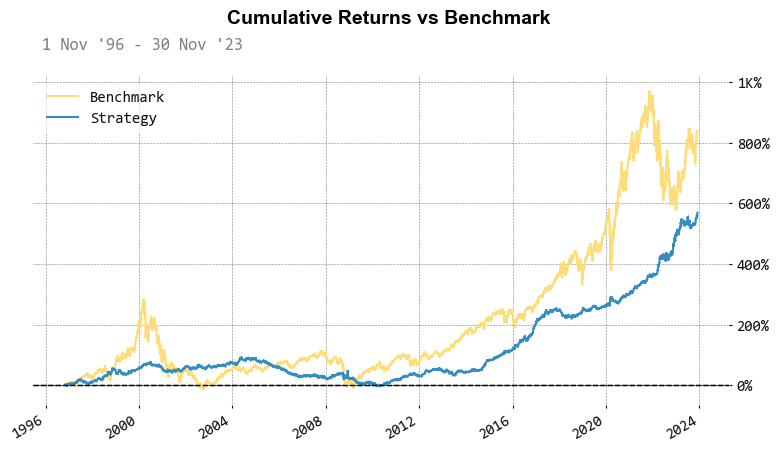

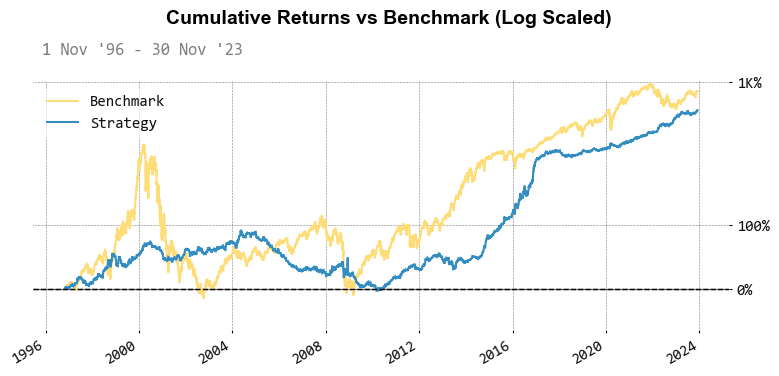

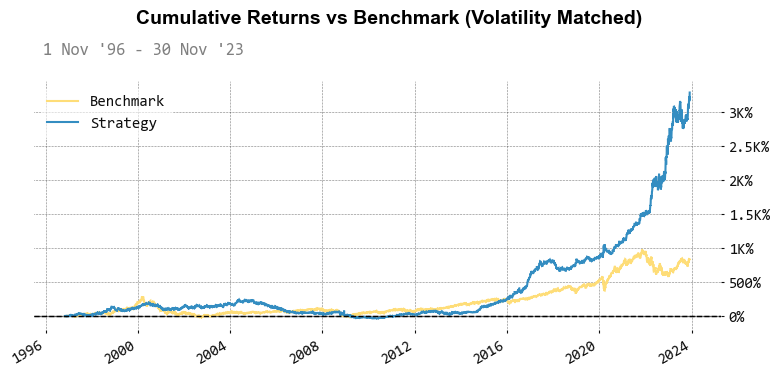

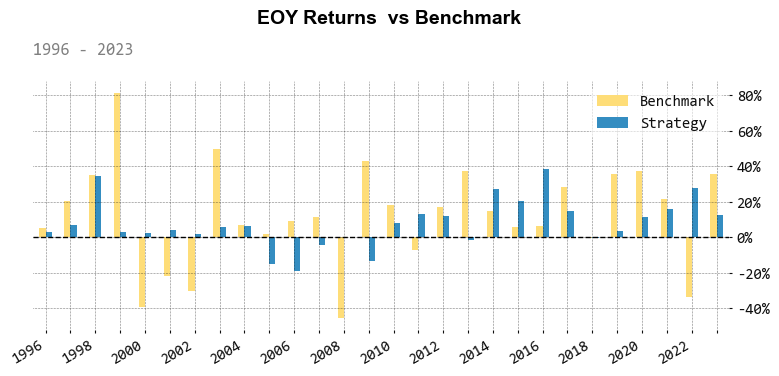

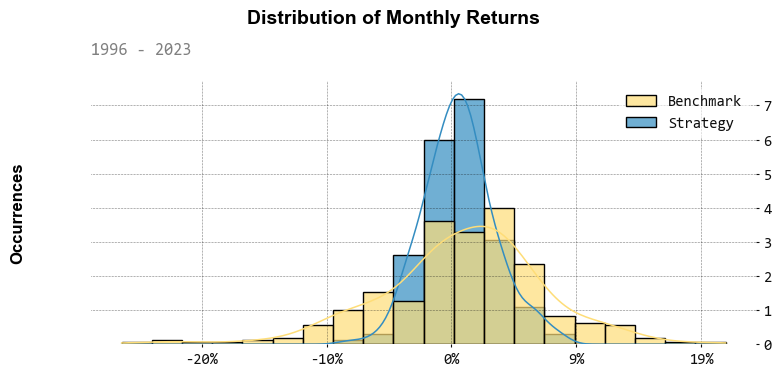

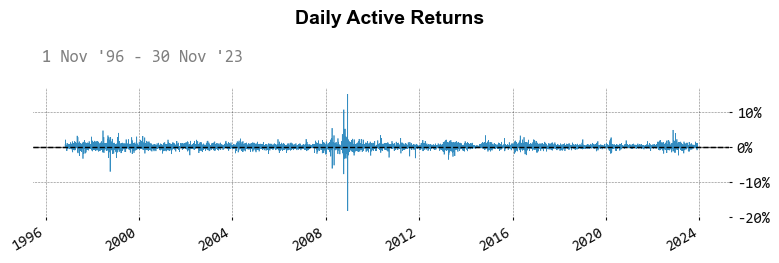

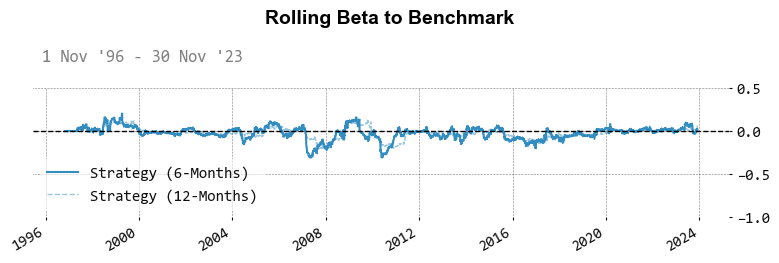

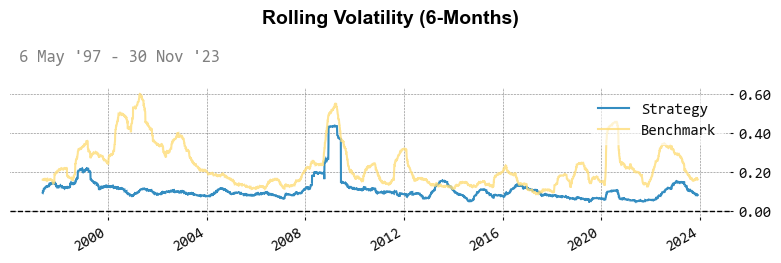

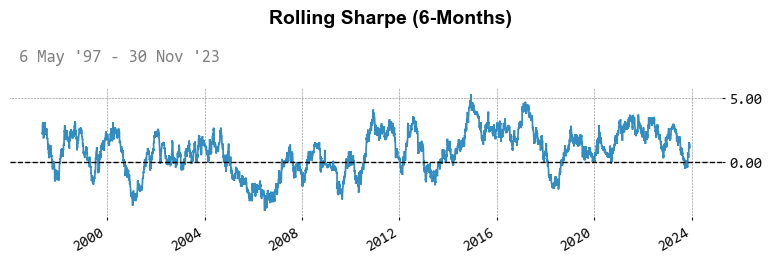

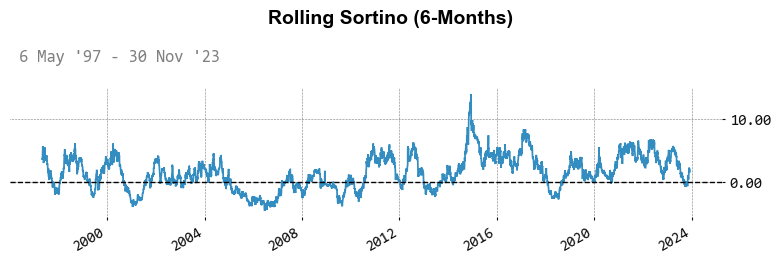

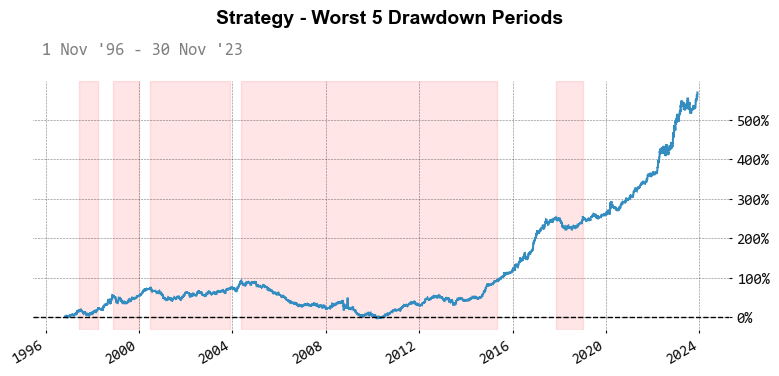

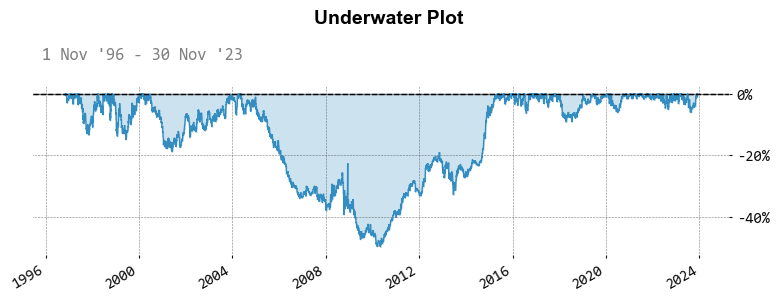

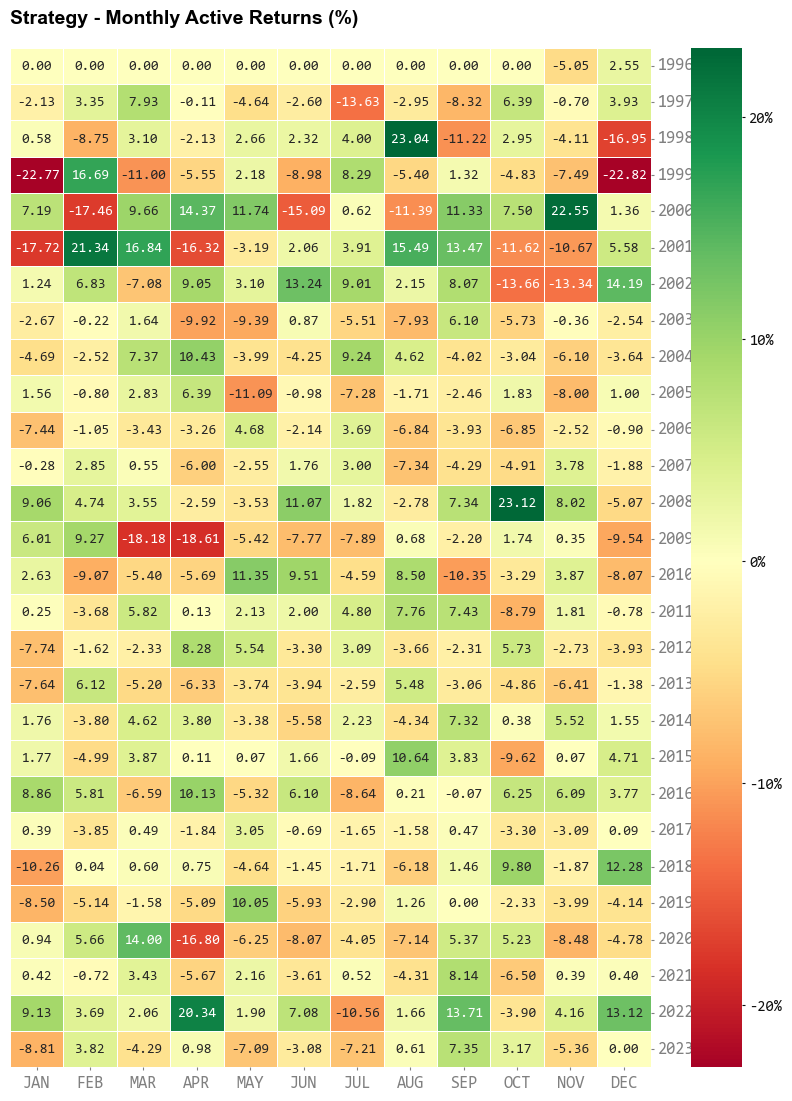

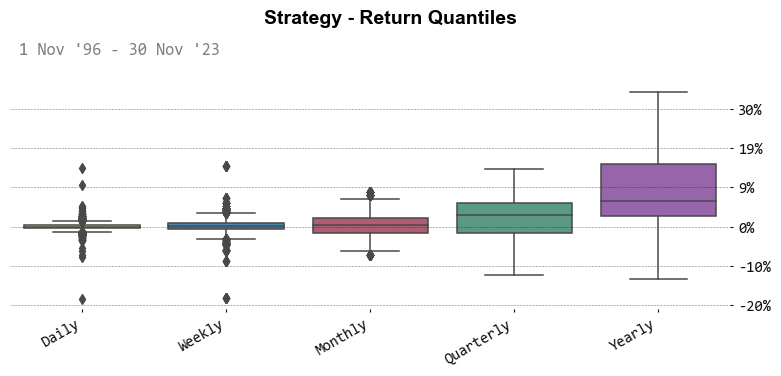

In [60]:
 qs.reports.full(df_temp['JPYUSD'], benchmark=df_temp['Nasdaq'], rf=0.05)

In [95]:
dist = prep_dist(ret_boostp)


<AxesSubplot: xlabel='Date'>

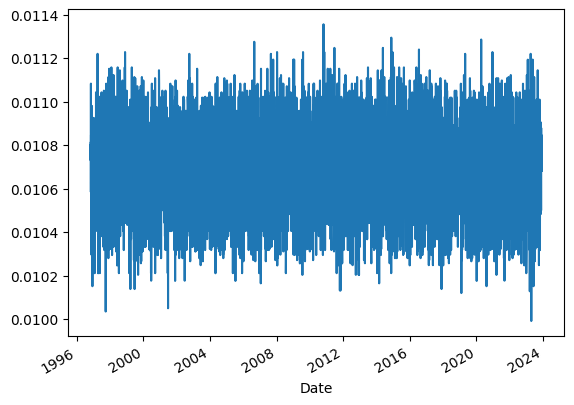

In [110]:
dist['0.95'].plot()

In [91]:
dist_cum = ep.cum_returns(dist, starting_value=1)



In [108]:
pd.set_option('display.float_format', str)
round(dist_cum['0.95'],2)


Date
1996-10-31                     1.01
1996-11-01                     1.02
1996-11-04                     1.03
1996-11-05                     1.04
1996-11-06                     1.06
                      ...          
2023-11-24   1.9942335312055764e+31
2023-11-27   2.0155537032324238e+31
2023-11-28    2.037072426927279e+31
2023-11-29     2.05916817352098e+31
2023-11-30    2.081163849844714e+31
Name: 0.95, Length: 6775, dtype: float64

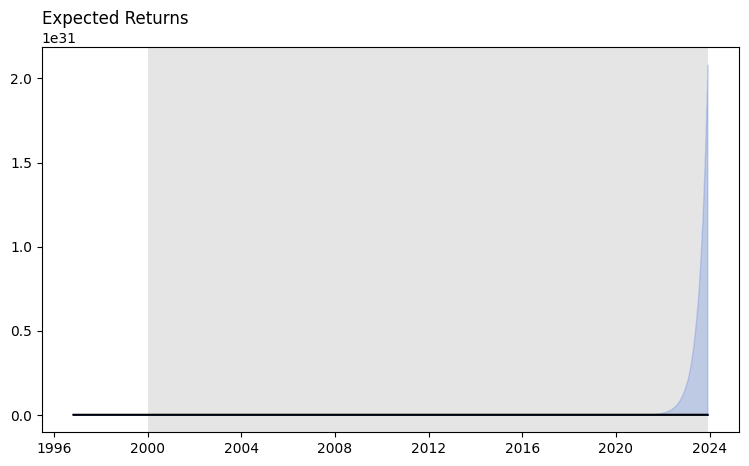

In [101]:
plot_fan_chart(df_temp[['JPYUSD']],dist_cum, out_of_sample_date='2000-01-01',
                   starting_value=1,
                   chart_title='Expected Returns')

In [112]:
from fanchart import load_boe_history, load_boe_parameters
from fanchart import fan

history = load_boe_history()
parameters = load_boe_parameters()
    


Loading 2022Q3 historic CPI inflation data  - as published by the BoE.
Loading 2022Q3 parameters - as published by the BoE.


In [126]:
history

,Date,Inflation
0,2004-01-01 00:00:00,1.3
1,2004-04-01 00:00:00,1.4
2,2004-07-01 00:00:00,1.3
3,2004-10-01 00:00:00,1.4
4,2005-01-01 00:00:00,1.7
...,...,...
69,2021-04-01 00:00:00,2.1
70,2021-07-01 00:00:00,2.8
71,2021-10-01 00:00:00,4.9
72,2022-01-01 00:00:00,6.2


In [115]:
probs = [0.05, 0.20, 0.35, 0.65,0.80,  0.95]
parameters

,Date,Mode,Uncertainty,Skewness
0,2022-07-01 00:00:00,9.93,0.69,0.0
1,2022-10-01 00:00:00,13.1,1.01,0.0
2,2023-01-01 00:00:00,12.56,1.35,0.26
3,2023-04-01 00:00:00,10.79,1.55,1.08
4,2023-07-01 00:00:00,9.53,1.68,1.0
5,2023-10-01 00:00:00,5.46,1.71,0.9
6,2024-01-01 00:00:00,4.33,1.74,0.71
7,2024-04-01 00:00:00,2.64,1.76,-0.13
8,2024-07-01 00:00:00,2.0,1.81,-0.08
9,2024-10-01 00:00:00,1.4,1.81,-0.05


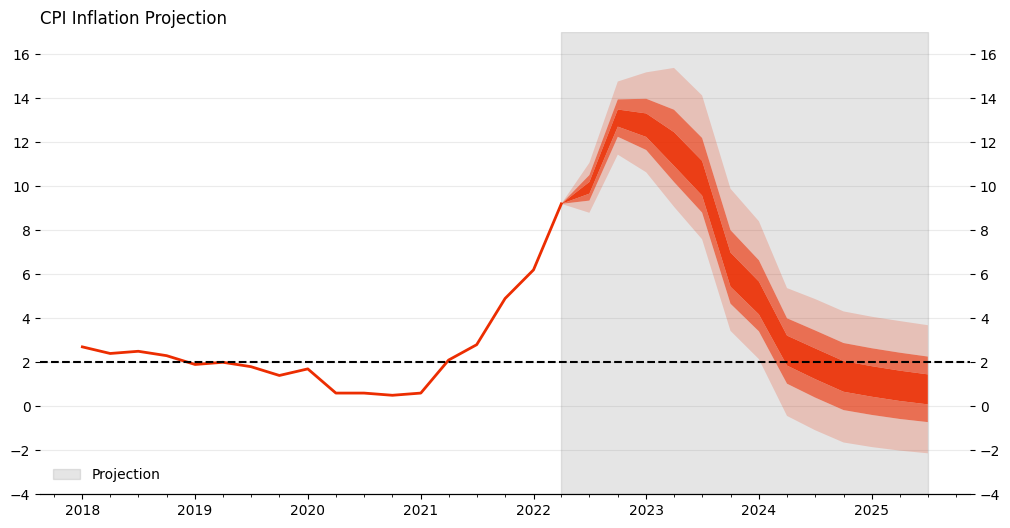

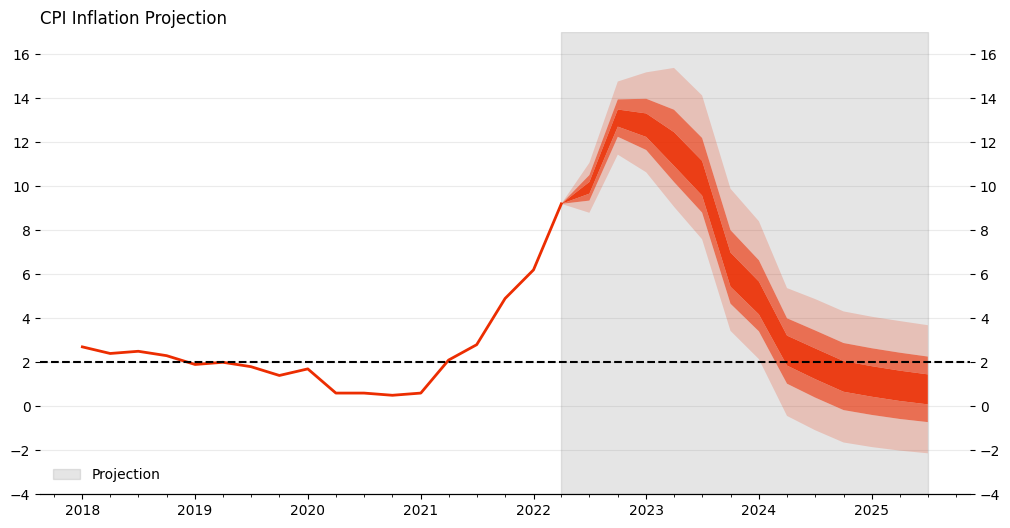

In [114]:
fan(pars=parameters, probs=probs, historic=history[history.Date >= '2018'])

In [125]:
param = pd.concat([ret_boostp.median(axis=1), ret_boostp.std(axis=1), ret_boostp.skew(axis=1)], axis=1)
param.columns = ['Mode','Uncertainty', 'Skewness']
param = param.reset_index()
param

,Date,Mode,Uncertainty,Skewness
0,1996-10-31,0.0001911612907061766,0.0075365706689332216,2.429646104639407
1,1996-11-01,0.00015944676511623363,0.007814539244993429,2.190316641550272
2,1996-11-04,9.017478103690024e-05,0.00803457840393571,-4.697281154453801
3,1996-11-05,0.00018707620401609004,0.007302897300544158,3.7515421182461055
4,1996-11-06,0.00026528232756900527,0.008016565181172044,-0.6766082105353594
...,...,...,...,...
6770,2023-11-24,0.00016077909596196038,0.006999355230826663,-0.5342653647162758
6771,2023-11-27,0.00027103633932363847,0.007072374727198727,1.2505358005269205
6772,2023-11-28,0.0001796523266168748,0.007184622788244555,-1.701348631272377
6773,2023-11-29,0.00016782145126870152,0.007516363126015997,2.026958931645792


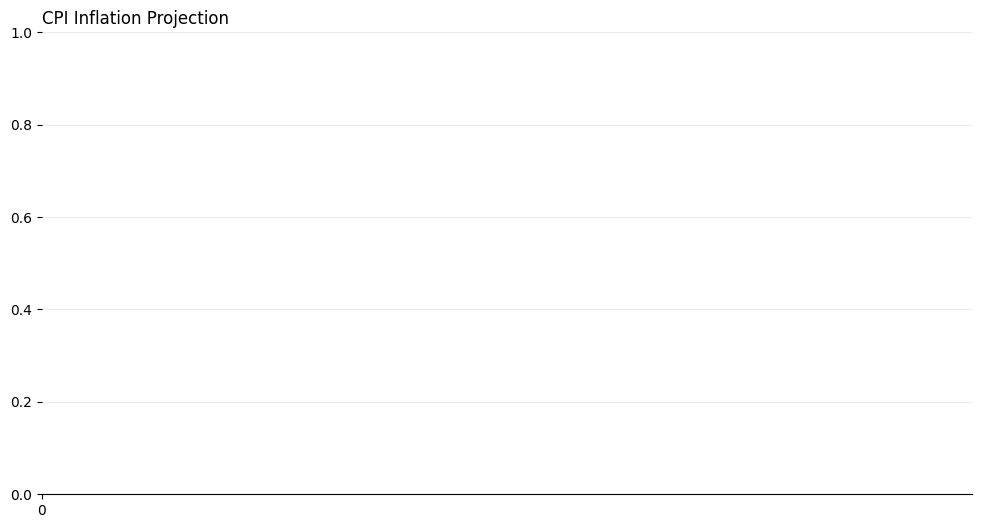

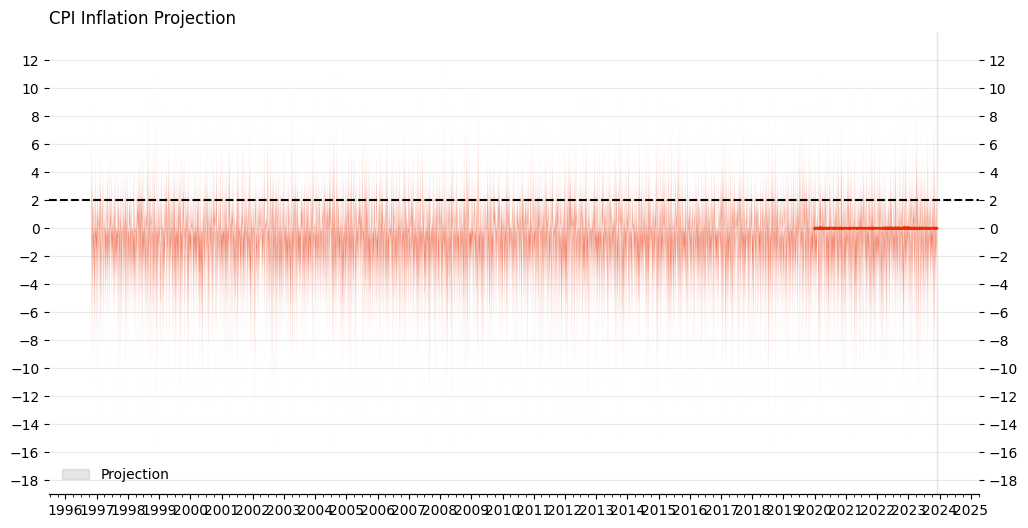

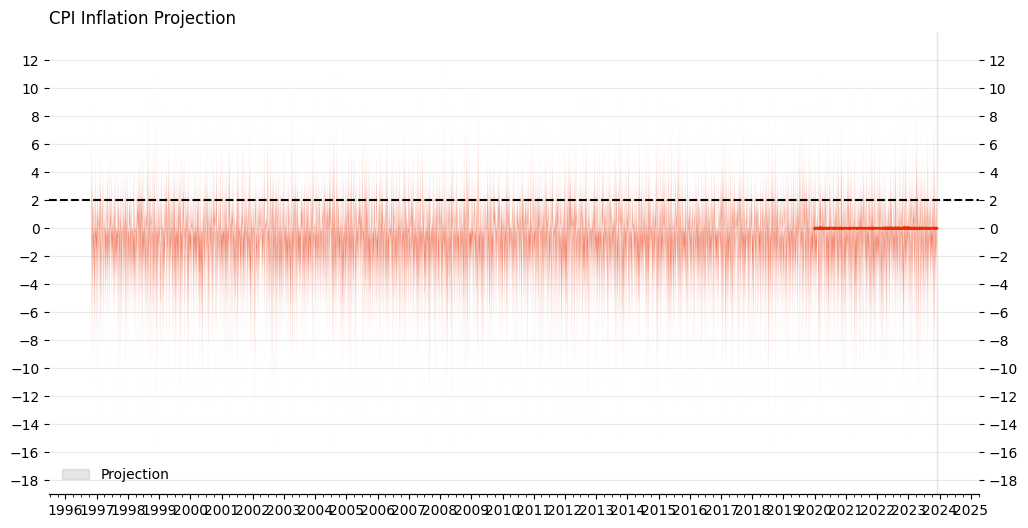

In [128]:
hist = df_temp[['JPYUSD']].reset_index()
hist = hist.rename(columns={'JPYUSD':'Inflation'})
fan(pars=param, probs=probs, historic=hist[hist.Date >= '2020'])